In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

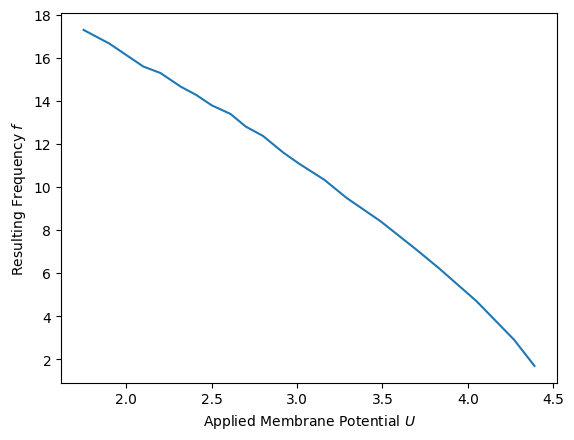

In [7]:
pot, pot_error, freq, freq_error = np.loadtxt("freq_vs_current.txt", skiprows=1, delimiter=",").T

plt.plot(pot, freq)
plt.xlabel("Applied Membrane Potential $U$")
plt.ylabel("Resulting Frequency $f$")
plt.show()

Derive an equation for $f_{theo}(I)$. Your function should depend on the chosen parametrization of the LIF equation,
namely $ϑ$, $C_m$, $R$, and $τ_{ref}$. Here $R$ is the membrane resistance of the Lu.i. board, the inverse of the membrane
conductance, and $C_m$ is the membrane capacitance. You might need to define your integration limits. (Hint 1:
Consult equation (1.2) as a starting point; hint 2: You’ll find $R \cdot I > ϑ$ as a condition)

Fit the function to your measurements. You might find it helpful to extract the membrane capacitance value from
the circuit diagram.

$$
\tau_{mem} = RC \\
f_{theo}(I) = \frac{1}{T(I)} \\
T(I) = \tau_{ref} + t_{charge} \\
\text{We want to find the time it takes to charge the capacitor to } \vartheta \\
\tau_{mem} \cdot \frac{d u_i}{dt}(t) = − [u_i(t) − u_{rest}] + R \cdot I(t) \\
I(t) \text{ is constant in this experiment} \\
\frac{d u_i}{dt}(t) = (− [u_i(t) − u_{rest}] + R I) \cdot \frac{1}{\tau_{mem}} \\
u_i(t) = u_{rest} + RI(1 - e^{-\frac{t}{\tau_{mem}}}) \\
\vartheta = u_i(t) \\
\frac{\vartheta - u_{rest}}{RI} = 1 - e^{-\frac{t}{\tau_{mem}}} \\
e^{-\frac{t}{\tau_{mem}}} = 1 - \frac{\vartheta - u_{rest}}{RI} \\
t_{charge} = - \tau_{mem} \ln (1 - \frac{\vartheta - u_{rest}}{RI}) \\
t_{charge} = \tau_{mem} \ln (\frac{RI}{RI - \vartheta + u_{rest}}) \\
f_{theo}(I) = (\tau_{ref} + \tau_{mem} \ln (\frac{RI}{RI - \vartheta + u_{rest}}))^{-1}
$$

In [8]:
def freq_from_I_fitfunc(I, tau_ref, C, R, theta):
    u_rest = 0.003
    t_charge = R * C * np.log(R * I / (R * I - theta + u_rest))
    return 1/(tau_ref + t_charge)

parameter_names = ['tau_ref', 'C', 'R', 'theta']

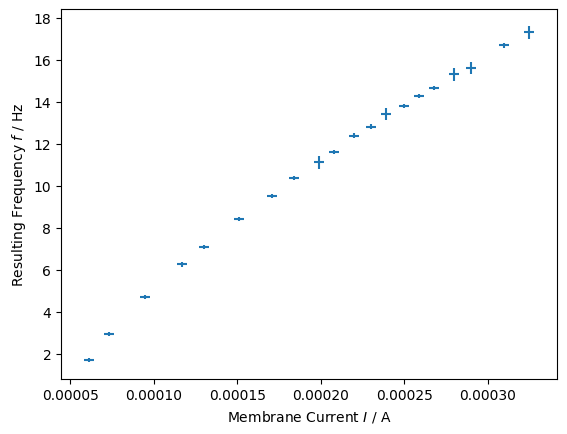

In [9]:
V_CC = 5    # V
R_sense = 10000    # Ohm
I = (V_CC - pot) / R_sense
I_error = pot_error / R_sense

def plot_freq_vs_I():
    plt.errorbar(I, freq, xerr = I_error, yerr = freq_error, linestyle='')
    plt.xlabel("Membrane Current $I$ / A")
    plt.ylabel("Resulting Frequency $f$ / Hz")
    plt.show()

plot_freq_vs_I()

['tau_ref', 'C', 'R', 'theta']
[1.56933154e-02 1.45228768e-05 1.53154166e+04 8.63487517e-01]
[[ 7.33583066e-07 -4.05165605e-04  4.27275953e+05  2.40062489e+01]
 [-4.05165605e-04  1.29448155e+00 -1.36512380e+09 -7.66986597e+04]
 [ 4.27275953e+05 -1.36512380e+09  1.43962113e+18  8.08842473e+13]
 [ 2.40062489e+01 -7.66986597e+04  8.08842473e+13  4.54443278e+09]]


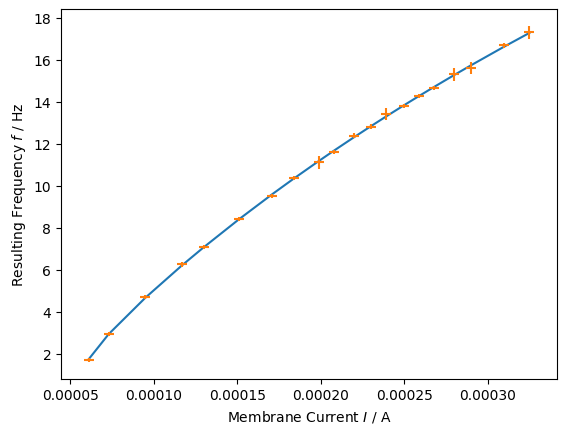

In [11]:
p0 = [
    12.6* 10**-3,
    22e-6,
    100000,
    1.2
]

popt, pcov = curve_fit(
    freq_from_I_fitfunc,
    I,
    freq,
    p0 = p0,
    sigma = freq_error,
    absolute_sigma = True
)

print(parameter_names)
print(popt)
print(pcov)

# plt.plot(I, freq_from_I_fitfunc(I, *p0))
plt.plot(I, freq_from_I_fitfunc(I, *popt))
plot_freq_vs_I()